## Introduction
Anomaly detection in video surveillance is critical for ensuring public safety, as manual monitoring of numerous video feeds is often challenging and prone to human error. Security operators can struggle to maintain focus over prolonged periods, leading to missed events or delayed responses.An automated system can help mitigate this by providing continuous, reliable monitoring and rapid anomaly detection. In response to these challenges, we propose AnomLite, a lightweight yet effective model designed to detect anomalies in video streams through a hybrid architecture. The initial layers of MobileNetV2 are employed for efficient spatial feature extraction, capturing low-to-mid-level features such as edges and textures, while the last hidden state of an LSTM processes temporal dependencies to identify patterns indicative of anomalies. AnomLite is competitive due to its computational efficiency, requiring only 11 million parameters, and its robustness, achieving a ROC AUC of 0.99, Average Precision of 0.99 and F1-Score (Weighted) of 0.92 and outperforming comparable models in anomaly detection tasks. These attributes make AnomLite suitable for real-time applications in resource-constrained environments like urban centers and public transport hubs.

#Dataset loading

In [ ]:
# === Dataset Configuration ===
# On Kaggle: Data is preloaded at /kaggle/input/
# On Colab: Uncomment the download section below

import os

# Detect platform and set paths accordingly
if os.path.exists('/kaggle/input/ucf-crime-dataset'):
    # Running on Kaggle - data is already available
    TRAIN_DIR = '/kaggle/input/ucf-crime-dataset/Train'
    TEST_DIR = '/kaggle/input/ucf-crime-dataset/Test'
else:
    # Running on Colab or locally - download the dataset first
    # !pip install kaggle
    # !kaggle datasets download -d odins0n/ucf-crime-dataset --unzip -p /content
    TRAIN_DIR = '/content/Train'
    TEST_DIR = '/content/Test'

SEED = 42
NUM_CLASSES = 14
CLASS_NAMES = [
    'Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary',
    'Explosion', 'Fighting', 'RoadAccidents', 'Robbery',
    'Shooting', 'Shoplifting', 'Stealing', 'Vandalism', 'NormalVideos'
]
CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}

print(f'Train directory: {TRAIN_DIR}')
print(f'Test directory: {TEST_DIR}')


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except:
    IN_COLAB = False
    print('Not running in Colab, skipping drive mount')


In [ ]:
import glob
import os
def correct_normal_videos_class(folder_path):
  for pic_path in glob.glob(os.path.join(folder_path, 'Normal_Videos/*.png')):
    os.rename(pic_path, pic_path.replace('Normal_Videos', 'NormalVideos'))

correct_normal_videos_class('/kaggle/input/ucf-crime-dataset/Train')
correct_normal_videos_class('/kaggle/input/ucf-crime-dataset/Test')

#EDA

####Create the VideoDataset class
without any transformations to understand how many video clips we have in the dataset and in which classes.

In [ ]:
# === Custom Video Dataset Loader ===
# PyTorch Dataset that loads video frames, groups them by video ID,
# and applies preprocessing (downsampling, normalization).

import os
import glob
import torch
from torch.utils.data import Dataset
import numpy as np
from PIL import Image
from torchvision import transforms
import re

class VideoDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.videos_info = [] # Video info: tuple list (frame paths, class)

        for class_folder in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_folder)
            if not os.path.isdir(class_path):
                continue  # Skip if it's not a directory
            class_idx = class_folder

            video_frames = {}
            for frame_file in glob.glob(os.path.join(class_path, '*.png')):
                match = re.search(r'\d+', frame_file)  # Extract the numeric video ID from the file name
                if match:
                    video_id = int(match.group())  # Convert to a number
                    if video_id not in video_frames:
                        video_frames[video_id] = [] # Create a new video
                    video_frames[video_id].append(frame_file)

            for video_id, frames in video_frames.items():
                if frames:  # Checking to see if there are any frames
                    self.videos_info.append((sorted(frames), class_idx)) # Add video information

    def __len__(self):
        return len(self.videos_info)

    def __getitem__(self, idx):
        frames_paths, class_name = self.videos_info[idx]
        frames = [Image.open(frame_path) for frame_path in frames_paths]

        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        frames_tensors = torch.stack([transform(frame) for frame in frames])

        return frames_tensors, class_name

root_dir = '/kaggle/input/ucf-crime-dataset/Train'
dataset = VideoDataset(root_dir=root_dir)
print(f"Dataset length: {len(dataset)}")



Dataset length: 1610


In [ ]:
from collections import defaultdict

dataset = VideoDataset('/kaggle/input/ucf-crime-dataset/Train')

video_count_per_class = defaultdict(int)

for _, class_name in dataset:
    video_count_per_class[class_name] += 1

for class_name, count in video_count_per_class.items():
    print(f"Class: {class_name}, Number of videos: {count}")

Class: Vandalism, Number of videos: 45
Class: Arrest, Number of videos: 45
Class: Explosion, Number of videos: 29
Class: Arson, Number of videos: 41
Class: Stealing, Number of videos: 95
Class: RoadAccidents, Number of videos: 127
Class: Shooting, Number of videos: 27
Class: Fighting, Number of videos: 45
Class: Robbery, Number of videos: 145
Class: Abuse, Number of videos: 48
Class: Shoplifting, Number of videos: 29
Class: Burglary, Number of videos: 87
Class: NormalVideos, Number of videos: 800
Class: Assault, Number of videos: 47


In [ ]:

frames_count = []

for i in range(len(dataset)):
    video_tensor, _ = dataset[i]
    frames_count.append(video_tensor.shape[0])  # video_tensor.shape[0] gives the number of frames in the video

if len(set(frames_count)) == 1:
    print(f"All videos have the same number of frames: {frames_count[0]}")
else:
    print("Videos have different frame counts.")
    print(f"Minimum number of frames: {min(frames_count)}")
    print(f"Maximum number of frames: {max(frames_count)}")

Videos have different frame counts.
Minimum number of frames: 11
Maximum number of frames: 97651


I have very different videos in terms of frame count. Let's take a closer look at the length distribution

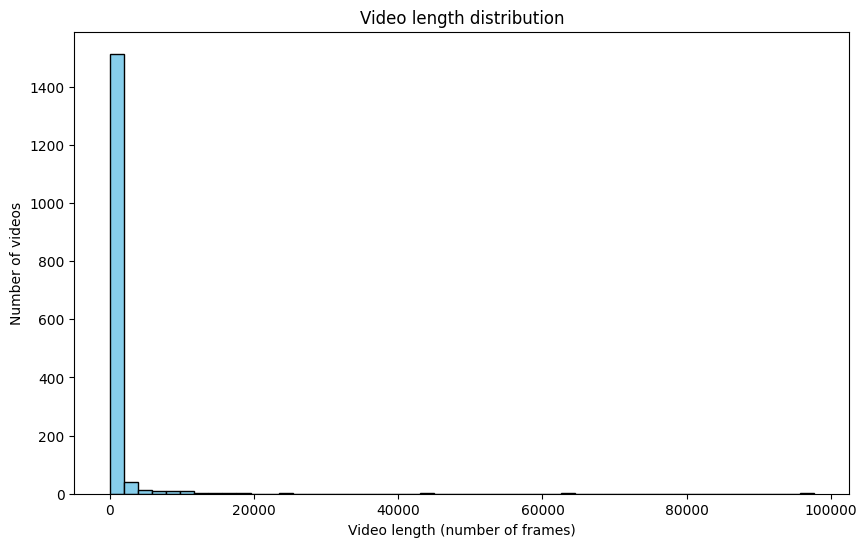

Minimum video length: 11
Maximum video length: 97651
Average video length: 786.55
Median length video: 222.5


In [ ]:
import matplotlib.pyplot as plt

video_lengths = [len(info[0]) for info in dataset.videos_info]

plt.figure(figsize=(10, 6))
plt.hist(video_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Video length distribution')
plt.xlabel('Video length (number of frames)')
plt.ylabel('Number of videos')
plt.show()

print(f"Minimum video length: {min(video_lengths)}")
print(f"Maximum video length: {max(video_lengths)}")
print(f"Average video length: {np.mean(video_lengths):.2f}")
print(f"Median length video: {np.median(video_lengths)}")


####Objects over 10,000 frames
You can see that after 10,000 frames there are outliers

In [ ]:
video_lengths = [len(info[0]) for info in dataset.videos_info]
video_classes = [info[1] for info in dataset.videos_info]

threshold = 10000

videos_above_threshold = sum(length > threshold for length in video_lengths)
print(f"The number of videos with more than {threshold} frames: {videos_above_threshold}")

classes_above_threshold = [class_name for length, class_name in zip(video_lengths, video_classes) if length > threshold]

from collections import Counter
class_counts = Counter(classes_above_threshold)
print("Number of videos with more than 10 thousand frames per class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")


The number of videos with more than 10000 frames: 20
Number of videos with more than 10 thousand frames per class:
Explosion: 1
Arson: 1
NormalVideos: 18


####class VideoDataset up to 10 thousand frames

In [ ]:
# === Custom Video Dataset Loader ===
# PyTorch Dataset that loads video frames, groups them by video ID,
# and applies preprocessing (downsampling, normalization).

class VideoDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.videos_info = []  # Video info: list of tuples (paths to frames, class)
        self.threshold = 10000  # Threshold for maximum video length
        excluded_classes = ['Explosion', 'Arson', 'NormalVideos']  # Classes to exclude when exceeding the threshold

        for class_folder in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_folder)
            if not os.path.isdir(class_path):
                continue  # Skip if it's not a directory
            class_idx = class_folder  # The folder name corresponds to the class

            video_frames = {}
            for frame_file in glob.glob(os.path.join(class_path, '*.png')):
                match = re.search(r'\d+', frame_file)  # Extracting numeric video ID from file name
                if match:
                    video_id = int(match.group())  # Convert to number
                    if video_id not in video_frames:
                        video_frames[video_id] = []  # Create a new video clip
                    video_frames[video_id].append(frame_file)

            for video_id, frames in video_frames.items():
                if frames and (len(frames) <= self.threshold or class_idx not in excluded_classes):
                    self.videos_info.append((sorted(frames), class_idx))  # Add information about the video clip

    def __len__(self):
        return len(self.videos_info)

    def __getitem__(self, idx):
        frames_paths, class_name = self.videos_info[idx]
        frames_paths = frames_paths[::2]  # Take every second frame

        frames = [Image.open(frame_path) for frame_path in frames_paths]

        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),  # Convert to grayscale image
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485], std=[0.229])  # Updated normalization parameters for one channel
        ])
        frames_tensors = torch.stack([transform(frame) for frame in frames])

        return frames_tensors, class_name

root_dir = '/kaggle/input/ucf-crime-dataset/Train'
dataset = VideoDataset(root_dir=root_dir)
print(f"Dataset length: {len(dataset)}")


Dataset length: 1590


##Distribution up to 10,000 frames

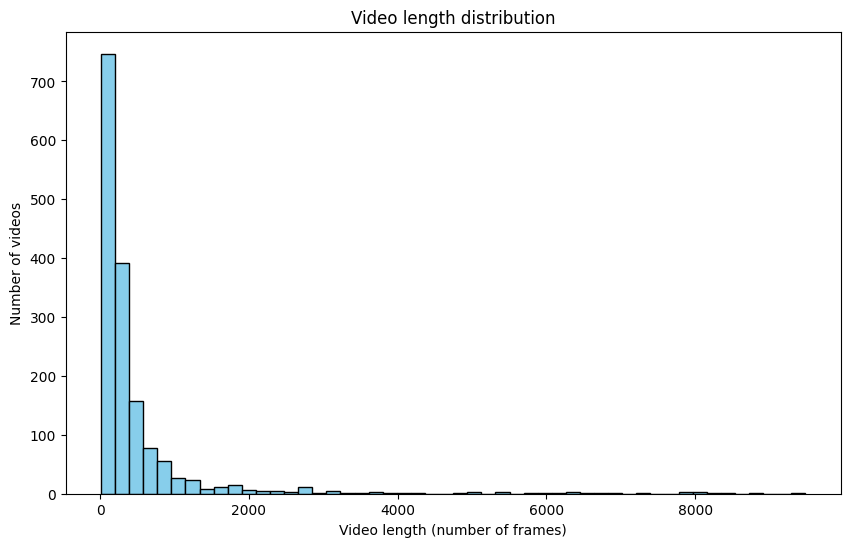

Minimum video length: 11
Maximum video length: 9480
Average video length: 516.39
Median length video: 219.0


In [ ]:
import matplotlib.pyplot as plt

video_lengths = [len(info[0]) for info in dataset.videos_info]

plt.figure(figsize=(10, 6))
plt.hist(video_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Video length distribution')
plt.xlabel('Video length (number of frames)')
plt.ylabel('Number of videos')
plt.show()

print(f"Minimum video length: {min(video_lengths)}")
print(f"Maximum video length: {max(video_lengths)}")
print(f"Average video length: {np.mean(video_lengths):.2f}")
print(f"Median length video: {np.median(video_lengths)}")

## Thresholds 4 and 2,500 frames ##

In [ ]:
video_lengths = [len(info[0]) for info in dataset.videos_info]
video_classes = [info[1] for info in dataset.videos_info]

threshold = 4000

videos_above_threshold = sum(length > threshold for length in video_lengths)
print(f"The number of videos with more than {threshold} frames: {videos_above_threshold}")

classes_above_threshold = [class_name for length, class_name in zip(video_lengths, video_classes) if length > threshold]

from collections import Counter
class_counts = Counter(classes_above_threshold)
print("Number of videos with more than 4 thousand frames by classes:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

The number of videos with more than 4000 frames: 34
Number of videos with more than 4 thousand frames by classes:
Arrest: 1
Shoplifting: 1
Burglary: 2
NormalVideos: 30


In [ ]:
video_lengths = [len(info[0]) for info in dataset.videos_info]
video_classes = [info[1] for info in dataset.videos_info]

threshold = 2500

videos_above_threshold = sum(length > threshold for length in video_lengths)
print(f"The number of videos with more than {threshold} frames: {videos_above_threshold}")

classes_above_threshold = [class_name for length, class_name in zip(video_lengths, video_classes) if length > threshold]

from collections import Counter
class_counts = Counter(classes_above_threshold)
print("Number of videos with more than 2,5 thousand frames by classes:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

The number of videos with more than 2500 frames: 62
Number of videos with more than 2,5 thousand frames by classes:
Arrest: 1
Fighting: 2
Abuse: 1
Shoplifting: 2
Burglary: 2
NormalVideos: 54


In [ ]:
# === Custom Video Dataset Loader ===
# PyTorch Dataset that loads video frames, groups them by video ID,
# and applies preprocessing (downsampling, normalization).

import os
import glob
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import re

class VideoDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.videos_info = []  # Video info: list of tuples (paths to frames, class)
        self.max_frames = 4000  # [Translated] [Translated] [Translated] [Translated] [Translated] [Translated]

        for class_folder in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_folder)
            if not os.path.isdir(class_path):
                continue  # Skip if it's not a directory
            class_idx = class_folder  # The folder name corresponds to the class

            video_frames = {}
            for frame_file in glob.glob(os.path.join(class_path, '*.png')):
                match = re.search(r'\d+', frame_file)  # Extracting numeric video ID from file name
                if match:
                    video_id = int(match.group())  # Convert to number
                    if video_id not in video_frames:
                        video_frames[video_id] = []  # Create a new video clip
                    video_frames[video_id].append(frame_file)

            for video_id, frames in video_frames.items():
                if frames and len(frames) <= self.max_frames:  # [Translated] [Translated] [Translated] [Translated]
                    self.videos_info.append((sorted(frames), class_idx))  # Add information about the video clip

    def __len__(self):
        return len(self.videos_info)

    def __getitem__(self, idx):
        frames_paths, class_name = self.videos_info[idx]
        frames = [Image.open(frame_path) for frame_path in frames_paths]

        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        frames_tensors = torch.stack([transform(frame) for frame in frames])

        return frames_tensors, class_name

root_dir = '/kaggle/input/ucf-crime-dataset/Train'
dataset = VideoDataset(root_dir=root_dir)
print(f"Dataset length: {len(dataset)}")

Dataset length: 1556


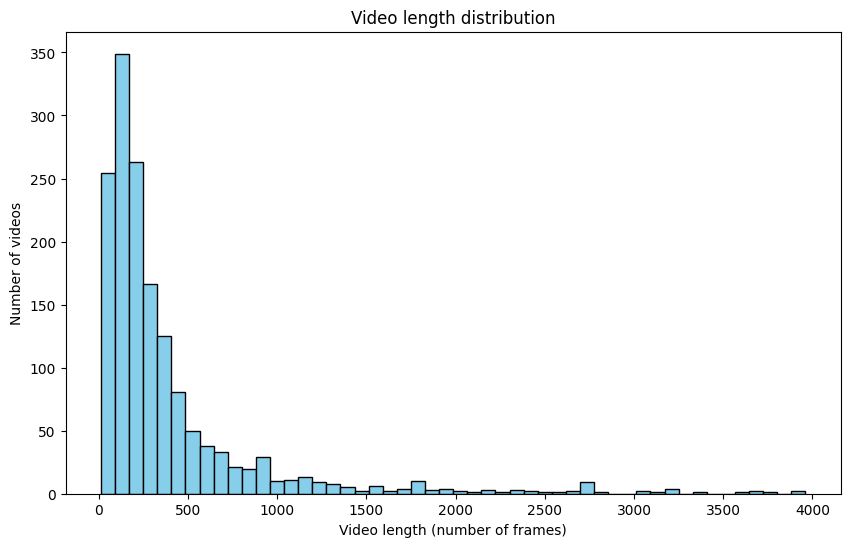

Minimum video length: 11
Maximum video length: 3961
Average video length: 387.24
Median length video: 212.5


In [ ]:

import matplotlib.pyplot as plt

video_lengths = [len(info[0]) for info in dataset.videos_info]

plt.figure(figsize=(10, 6))
plt.hist(video_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Video length distribution')
plt.xlabel('Video length (number of frames)')
plt.ylabel('Number of videos')
plt.show()

print(f"Minimum video length: {min(video_lengths)}")
print(f"Maximum video length: {max(video_lengths)}")
print(f"Average video length: {np.mean(video_lengths):.2f}")
print(f"Median length video: {np.median(video_lengths)}")

1. [Translated], [Translated] [Translated] [Translated] [Translated] 1500-2000, [Translated] [Translated] [Translated], [Translated] [Translated]

In [ ]:
video_lengths = [len(info[0]) for info in dataset.videos_info]
video_classes = [info[1] for info in dataset.videos_info]

threshold = 1500

videos_above_threshold = sum(length > threshold for length in video_lengths)
print(f"The number of videos with more than {threshold} frames: {videos_above_threshold}")

classes_above_threshold = [class_name for length, class_name in zip(video_lengths, video_classes) if length > threshold]

from collections import Counter
class_counts = Counter(classes_above_threshold)
print("Number of videos with more than 1,500 frames by class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

The number of videos with more than 1500 frames: 70
Number of videos with more than 1,500 frames by class:
Arrest: 1
Stealing: 5
RoadAccidents: 1
Fighting: 3
Robbery: 1
Abuse: 2
Shoplifting: 3
Burglary: 1
NormalVideos: 53


In [ ]:
# === Custom Video Dataset Loader ===
# PyTorch Dataset that loads video frames, groups them by video ID,
# and applies preprocessing (downsampling, normalization).

import os
import glob
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import re

class VideoDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.videos_info = []  # Video info: list of tuples (paths to frames, class)
        self.max_frames = 1500  # [Translated] [Translated] [Translated] [Translated] [Translated] [Translated]

        for class_folder in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_folder)
            if not os.path.isdir(class_path):
                continue  # Skip if it's not a directory
            class_idx = class_folder  # The folder name corresponds to the class

            video_frames = {}
            for frame_file in glob.glob(os.path.join(class_path, '*.png')):
                match = re.search(r'\d+', frame_file)  # Extracting numeric video ID from file name
                if match:
                    video_id = int(match.group())  # Convert to number
                    if video_id not in video_frames:
                        video_frames[video_id] = []  # Create a new video clip
                    video_frames[video_id].append(frame_file)

            for video_id, frames in video_frames.items():
                if frames and len(frames) <= self.max_frames:  # [Translated] [Translated] [Translated] [Translated]
                    self.videos_info.append((sorted(frames), class_idx))  # Add information about the video clip

    def __len__(self):
        return len(self.videos_info)

    def __getitem__(self, idx):
        frames_paths, class_name = self.videos_info[idx]
        frames = [Image.open(frame_path) for frame_path in frames_paths]

        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        frames_tensors = torch.stack([transform(frame) for frame in frames])

        return frames_tensors, class_name

root_dir = '/kaggle/input/ucf-crime-dataset/Train'
dataset = VideoDataset(root_dir=root_dir)
print(f"Dataset length: {len(dataset)}")

Dataset length: 1486


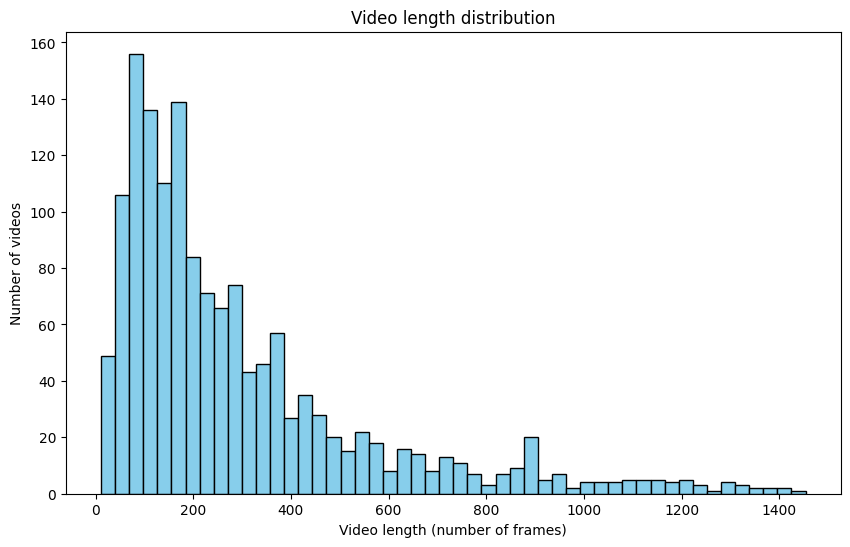

Minimum video length: 11
Maximum video length: 1454
Average video length: 294.52
Median length video: 198.0


In [ ]:

import matplotlib.pyplot as plt

video_lengths = [len(info[0]) for info in dataset.videos_info]

plt.figure(figsize=(10, 6))
plt.hist(video_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Video length distribution')
plt.xlabel('Video length (number of frames)')
plt.ylabel('Number of videos')
plt.show()

print(f"Minimum video length: {min(video_lengths)}")
print(f"Maximum video length: {max(video_lengths)}")
print(f"Average video length: {np.mean(video_lengths):.2f}")
print(f"Median length video: {np.median(video_lengths)}")

#Balance of classes

##The original balance of classes

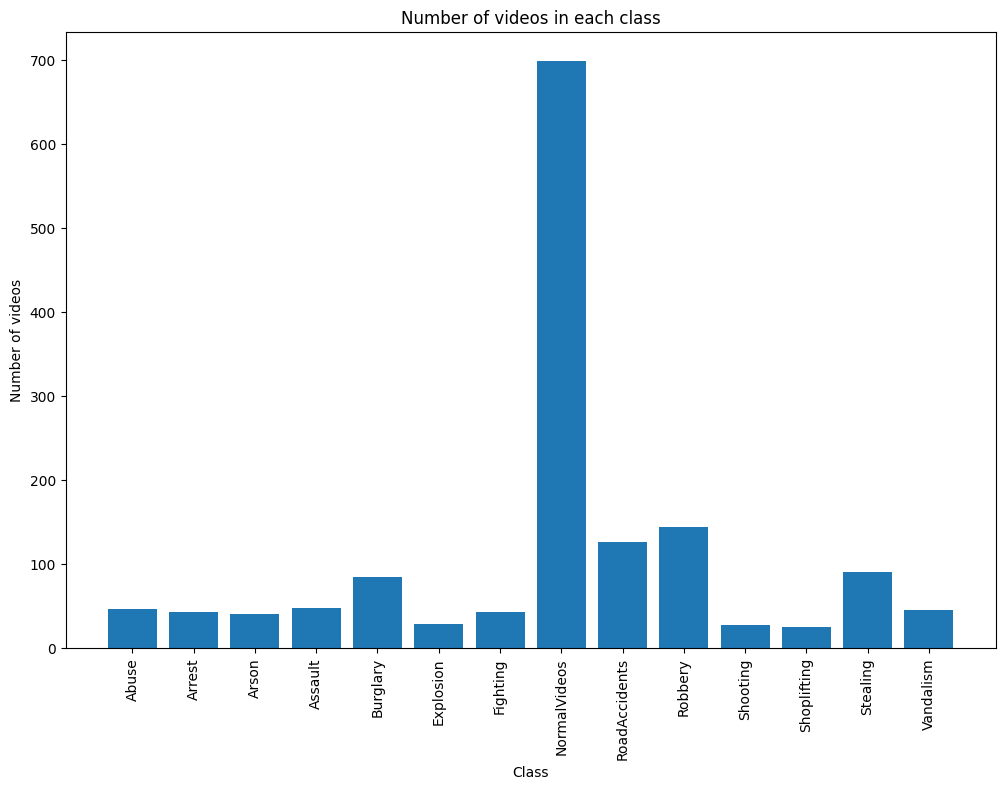

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

classes = [class_name for _, class_name in dataset.videos_info]

class_counts = Counter(classes)

sorted_class_counts = dict(sorted(class_counts.items()))

plt.figure(figsize=(12, 8))
plt.bar(range(len(sorted_class_counts)), list(sorted_class_counts.values()), align='center')
plt.xticks(range(len(sorted_class_counts)), list(sorted_class_counts.keys()), rotation=90)
plt.title('Number of videos in each class')
plt.xlabel('Class')
plt.ylabel('Number of videos')
plt.show()


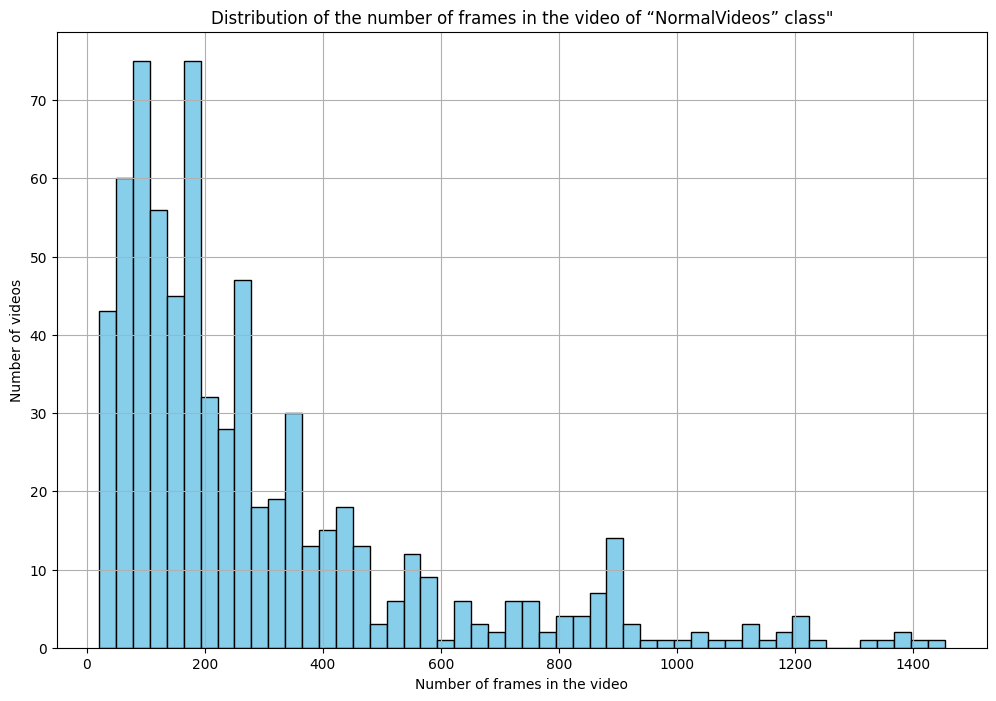

The minimum number of frames in a video of class 'NormalVideos': 21
The maximum number of frames in a video of class 'NormalVideos': 1454
The average number of frames in a video of class 'NormalVideos': 290.20


In [ ]:
normal_videos_frames_count = []

for video_info in dataset.videos_info:
    frames_paths, class_name = video_info
    if class_name == "NormalVideos":
        normal_videos_frames_count.append(len(frames_paths))

plt.figure(figsize=(12, 8))
plt.hist(normal_videos_frames_count, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of the number of frames in the video of “NormalVideos” class"')
plt.xlabel('Number of frames in the video')
plt.ylabel('Number of videos')
plt.grid(True)
plt.show()

if normal_videos_frames_count:
    print(f"The minimum number of frames in a video of class 'NormalVideos': {min(normal_videos_frames_count)}")
    print(f"The maximum number of frames in a video of class 'NormalVideos': {max(normal_videos_frames_count)}")
    print(f"The average number of frames in a video of class 'NormalVideos': {sum(normal_videos_frames_count) / len(normal_videos_frames_count):.2f}")
else:
    print("There are no videos of class 'NormalVideos' in the dataset or an error occurred during filtering.")


## Class balance at the 1,500 threshold

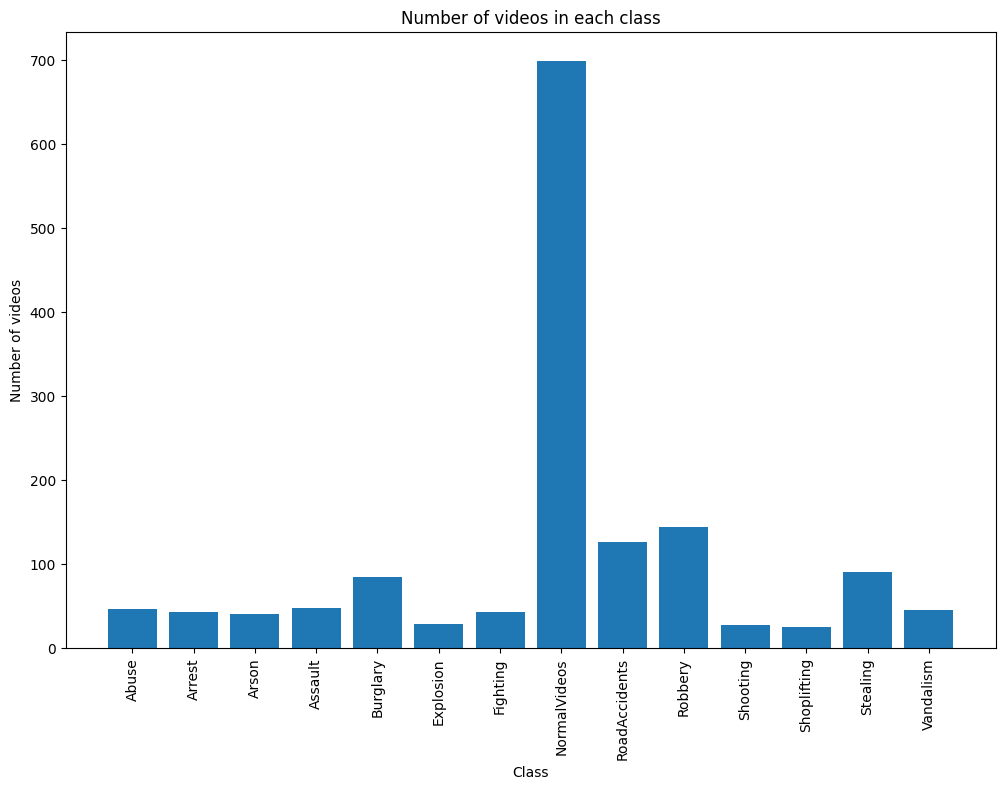

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

classes = [class_name for _, class_name in dataset.videos_info]

class_counts = Counter(classes)

sorted_class_counts = dict(sorted(class_counts.items()))

plt.figure(figsize=(12, 8))
plt.bar(range(len(sorted_class_counts)), list(sorted_class_counts.values()), align='center')
plt.xticks(range(len(sorted_class_counts)), list(sorted_class_counts.keys()), rotation=90)
plt.title('Number of videos in each class')
plt.xlabel('Class')
plt.ylabel('Number of videos')
plt.show()


##Conclusion: the dataset is still unbalanced with NormalVideos class predominating. To deal with such data, we apply class weighting for error calculation + f1 micro and f1 macro metrics.


#Metrics
In the task, F1 Micro, F1 Macro, loss, ROC AUC for binary classification will be used for evaluation


**F1 Micro**
F1 Micro is calculated based on the global sums of true positive (TP), false positive (FP) and false negative (FN) values across all classes:
$$
F1_{\text{micro}} = \frac{2 \cdot TP_{\text{micro}}}{2 \cdot TP_{\text{micro}} + FP_{\text{micro}} + FN_{\text{micro}}}
$$

**F1 Macro**
F1 Macro is calculated as the arithmetic mean of the F1-score for each class, without taking into account the proportion of each class:
$$
F1_{\text{macro}} = \frac{1}{N} \sum_{i=1}^{N} \frac{2 \cdot TP_i}{2 \cdot TP_i + FP_i + FN_i}
$$


### CrossEntropyLoss with weights
The cross-entropy loss function with class weighting can be expressed as follows:
$$
L = - \sum_{i=1}^{C} w_i \cdot y_i \cdot \log(p_i)
$$
Where:
- $C$ is the number of classes,
- $w_i$ is the weight for class $i$,
- $y_i$ is the true label of class $i$ (usually 0 or 1, depending on whether the example belongs to class $i$),
- $p_i$ is the predicted probability that the example belongs to class $i$.
### ROC AUC.
ROC (Receiver Operating Characteristic) AUC (Area Under the ROC Curve) is a measure used to evaluate the quality of binary classification and model selection based on the ratio between true positives and false positives at different thresholds. The ROC curve is plotted in TPR (True Positive Rate) and FPR (False Positive Rate) coordinates, and the AUC represents the area under this curve.
The formulas for TPR and FPR are:
$$
TPR = \frac{TP}{TP + FN}
$$
$$
FPR = \frac{FP}{FP + TN}
$$
Where:
- $TP$ is the number of true positives,
- $$FN$ - number of false negatives,
- $FP$ - number of false positives,
- $TN$ - number of true negatives.

#First round incorporating reviewers' comments

Dataset length: 1528


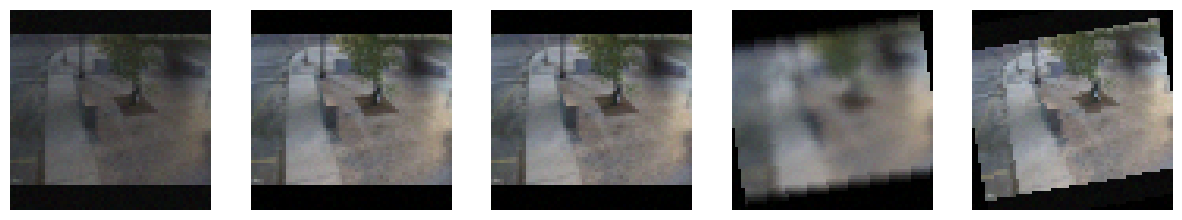

In [ ]:
# === Custom Video Dataset Loader ===
# PyTorch Dataset that loads video frames, groups them by video ID,
# and applies preprocessing (downsampling, normalization).

import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms.functional as F

class AddGaussianNoise(object):
    """[Translated] [Translated] [Translated] [Translated] [Translated]."""
    def __init__(self, mean=0., std=1.):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

    def __repr__(self):
        return self.__class__.__name__ + '(mean={0}, std={1})'.format(self.mean, self.std)

class VideoDataset(Dataset):
    def __init__(self, root_dir, transform=None, take_each_picture=2):
        self.root_dir = root_dir
        self.videos_info = []
        self.max_frames = 1000
        self.take_each_picture = take_each_picture
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((64, 64)),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=5)], p=0.3),
            transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=0.3)], p=0.3),
            transforms.RandomApply([transforms.RandomRotation(degrees=15)], p=0.2),
            AddGaussianNoise(mean=0.0, std=0.01),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        for class_folder in os.listdir(root_dir):
            class_path = os.path.join(root_dir, class_folder)
            if not os.path.isdir(class_path):
                continue  # Skip if it's not a directory
            class_idx = class_folder  # The folder name corresponds to the class

            video_frames = {}
            for frame_file in glob.glob(os.path.join(class_path, '*.png')):
                match = re.search(r'\d+', frame_file)  # Extracting numeric video ID from file name
                if match:
                    video_id = int(match.group())  # Convert to number
                    if video_id not in video_frames:
                        video_frames[video_id] = []  # Create a new video clip
                    video_frames[video_id].append(frame_file)

            for video_id, frames in video_frames.items():
                if frames and len(frames) <= self.max_frames:  # [Translated] [Translated] [Translated] [Translated]
                    self.videos_info.append((
                        self.sort_pictures_paths(np.array(frames)),
                        class_idx))  # Add information about the video clip

    def sort_pictures_paths(self, frames): # [Translated] [Translated] [Translated] пра[Translated]ильном [Translated]
        ids_of_sorted_pictures = np.argsort([
                     int(os.path.splitext(pic_path)[0].split('_')[-1])
                     for i, pic_path in enumerate(frames)])

        return frames[ids_of_sorted_pictures]

    def __len__(self):
        return len(self.videos_info)

    def __getitem__(self, idx):
        frames_paths, class_name = self.videos_info[idx]
        frames_paths = frames_paths[::self.take_each_picture]
        frames = [Image.open(frame_path).convert("RGB") for frame_path in frames_paths]  # [Translated], [Translated] [Translated] [Translated] RGB

        if self.transform:
            frames = [self.transform(frame) for frame in frames]

        return torch.stack(frames), class_name

root_dir = '/kaggle/input/ucf-crime-dataset/Train'
dataset = VideoDataset(root_dir=root_dir)

print(f"Dataset length: {len(dataset)}")

def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    tensor = tensor * std.view(3, 1, 1) + mean.view(3, 1, 1)
    tensor = tensor.clamp(0, 1)
    return tensor

if len(dataset) > 0:
    frames_tensors, _ = dataset[15]
    num_frames_to_display = min(5, len(frames_tensors))

    fig, axes = plt.subplots(1, num_frames_to_display, figsize=(15, 3))
    for i in range(num_frames_to_display):
        img = unnormalize(frames_tensors[i])
        img = F.to_pil_image(img)
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.show()
else:
    print("Dataset is empty.")


#Function def_collate and creation of DataLoaders

In [ ]:
import torch

CLASS_NAMES = [
    'Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary',
    'Explosion', 'Fighting', 'RoadAccidents', 'Robbery',
    'Shooting', 'Shoplifting', 'Stealing', 'Vandalism', 'NormalVideos'
]

CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}

def collate_batch(batch):
    max_frames = max(video.shape[0] for video, _ in batch)

    lengths_list = []
    videos_padded, classes_idx = [], []
    for video, class_name in batch:
        pad_size = max_frames - video.shape[0]

        if pad_size > 0:
            pad = torch.zeros(pad_size, *video.shape[1:], dtype=video.dtype)
            video_padded = torch.cat([video, pad], dim=0)  # Adding [Translated] [Translated] [Translated]
        else:
            video_padded = video

        videos_padded.append(video_padded)
        classes_idx.append(CLASS_TO_IDX[class_name])  # Transforming [Translated] [Translated] [Translated] [Translated]
        lengths_list.append(video.shape[0])

    videos_tensor = torch.stack(videos_padded)
    classes_tensor = torch.tensor(classes_idx, dtype=torch.long)
    lengths_tensor = torch.tensor(lengths_list, dtype=torch.long)


    return videos_tensor, classes_tensor, lengths_tensor

#Stratified separation into train and validation

In [ ]:
import os
import shutil
import glob
import re
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.3

train_folder = '/kaggle/input/ucf-crime-dataset/Train'
train_dataset = VideoDataset(train_folder)

list_pairs_label_name_and_videos = []
for class_folder in os.listdir(root_dir):
    class_path = os.path.join(root_dir, class_folder)
    label_name = class_folder

    video_frames = {}  # video_id -> list_of_paths_of_pictures
    for frame_file in glob.glob(os.path.join(class_path, '*.png')):
        match = re.search(r'\d+', frame_file)
        if match:
            video_id = int(match.group())
            if video_id not in video_frames:
                video_frames[video_id] = []
            video_frames[video_id].append(frame_file)
    for video in video_frames.values():
        list_pairs_label_name_and_videos.append((label_name, video))

label_names = [pair[0] for pair in list_pairs_label_name_and_videos]
train_pairs_label_name_and_videos, val_pairs_label_name_and_videos = \
    train_test_split(list_pairs_label_name_and_videos, test_size=TEST_SIZE, stratify=label_names, shuffle=True)

divided_train_folder_path = '/content/divided_train'
divided_val_folder_path = '/content/divided_val'

def copy_files_to_folder_with_structure(pairs_label_name_and_videos, result_dir):
    os.makedirs(result_dir, exist_ok=True)
    for label_name, pictures_paths in pairs_label_name_and_videos:
        new_class_folder = os.path.join(result_dir, label_name)
        os.makedirs(new_class_folder, exist_ok=True)
        for pic_path in pictures_paths:
            new_pic_path = os.path.join(new_class_folder, os.path.basename(pic_path))
            shutil.copyfile(pic_path, new_pic_path)

copy_files_to_folder_with_structure(train_pairs_label_name_and_videos, divided_train_folder_path)
copy_files_to_folder_with_structure(val_pairs_label_name_and_videos, divided_val_folder_path)


train_dataset = VideoDataset(divided_train_folder_path)
val_dataset = VideoDataset(divided_val_folder_path)


In [ ]:
print("Number of train samples:", len(train_pairs_label_name_and_videos))
print("Number of validation samples:", len(val_pairs_label_name_and_videos))

print("First 5 train samples:", train_pairs_label_name_and_videos[:5])
print("First 5 validation samples:", val_pairs_label_name_and_videos[:5])

Number of train samples: 1127
Number of validation samples: 483
First 5 train samples: [('Assault', ['/content/Train/Assault/Assault014_x264_560.png', '/content/Train/Assault/Assault014_x264_1280.png', '/content/Train/Assault/Assault014_x264_1250.png', '/content/Train/Assault/Assault014_x264_1330.png', '/content/Train/Assault/Assault014_x264_890.png', '/content/Train/Assault/Assault014_x264_460.png', '/content/Train/Assault/Assault014_x264_870.png', '/content/Train/Assault/Assault014_x264_590.png', '/content/Train/Assault/Assault014_x264_1650.png', '/content/Train/Assault/Assault014_x264_1800.png', '/content/Train/Assault/Assault014_x264_320.png', '/content/Train/Assault/Assault014_x264_830.png', '/content/Train/Assault/Assault014_x264_1700.png', '/content/Train/Assault/Assault014_x264_1480.png', '/content/Train/Assault/Assault014_x264_70.png', '/content/Train/Assault/Assault014_x264_1750.png', '/content/Train/Assault/Assault014_x264_230.png', '/content/Train/Assault/Assault014_x264_65

In [ ]:
desired_train_size = 170  # target
max_retries = 5           # Maximum number of retries
current_retry = 0

while current_retry < max_retries:
    train_dataset = VideoDataset(divided_train_folder_path)
    val_dataset = VideoDataset(divided_val_folder_path)

    train_size = len(train_dataset)
    print(f"Attempt {current_retry + 1}: Training dataset size = {train_size}")

    if train_size >= desired_train_size:
        print("Successfully loaded a large dataset!")
        break

    current_retry += 1

if train_size < desired_train_size:
    print("Could not load a dataset with the desired size.")

Attempt 1: Training dataset size = 1491
Successfully loaded a large dataset!


In [ ]:

from torch.utils.data import DataLoader
from torch.utils.data import random_split

BATCH_SIZE = 4

test_dataset = VideoDataset('/kaggle/input/ucf-crime-dataset/Test')



train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

dataloaders = {
    'train': train_dataloader,
    'val': val_dataloader
}

#Training

###CrossEntropyLoss

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn

labels = [CLASS_TO_IDX[label] for _, label in train_dataset]

class_weights = compute_class_weight('balanced', classes=np.arange(len(CLASS_NAMES)), y=labels)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to('cuda')

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [ ]:
class_weights


array([2.36564626, 2.36564626, 2.83877551, 2.36564626, 1.25768535,
       3.82142857, 2.48392857, 0.84920635, 0.74704619, 4.13988095,
       4.13988095, 1.15531561, 2.31063123, 0.1509987 ])

In [ ]:
CLASS_NAMES[13]

'NormalVideos'

###Focal loss experiment

```
# [Translated] [Translated] [Translated]
```



In [ ]:
import torch
import torch.nn as nn
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean'):
        """
        Focal Loss to address class imbalance.
        Args:
            alpha: Class weights (optional).
            gamma: Focusing parameter (default is 2).
            reduction: 'mean', 'sum', or 'none' for reducing the loss.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        Compute Focal Loss.
        Args:
            inputs: Logits from the model.
            targets: Ground truth class labels.
        """
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)  # Probability of the correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return torch.mean(focal_loss)
        elif self.reduction == 'sum':
            return torch.sum(focal_loss)
        else:
            return focal_loss


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn

labels = [CLASS_TO_IDX[label] for _, label in train_dataset]

class_weights = compute_class_weight('balanced', classes=np.arange(len(CLASS_NAMES)), y=labels)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to('cuda')

criterion = FocalLoss(alpha=class_weights_tensor, gamma=2, reduction='mean')

In [ ]:
class_weights

array([2.28246753, 2.51071429, 2.71428571, 2.33554817, 1.23985891,
       3.86263736, 2.57509158, 0.87329193, 0.74391534, 4.01714286,
       4.01714286, 1.12841091, 2.33554817, 0.15124785])

In [ ]:
CLASS_NAMES[13]

'NormalVideos'

#AnomLite

###Learning rates

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/20
----------


train: 100%|██████████| 173/173 [05:20<00:00,  1.85s/it]


train Loss: 2.9281 F1 Micro: 0.1196 F1 Macro: 0.0836


val: 100%|██████████| 98/98 [03:05<00:00,  1.90s/it]


...

val Loss: 0.8623 F1 Micro: 0.7997 F1 Macro: 0.7392
Epoch 20/20
----------


train: 100%|██████████| 173/173 [05:30<00:00,  1.91s/it]


train Loss: 0.3068 F1 Micro: 0.8529 F1 Macro: 0.8568


val: 100%|██████████| 98/98 [03:00<00:00,  1.84s/it]


val Loss: 0.9617 F1 Micro: 0.7869 F1 Macro: 0.7434


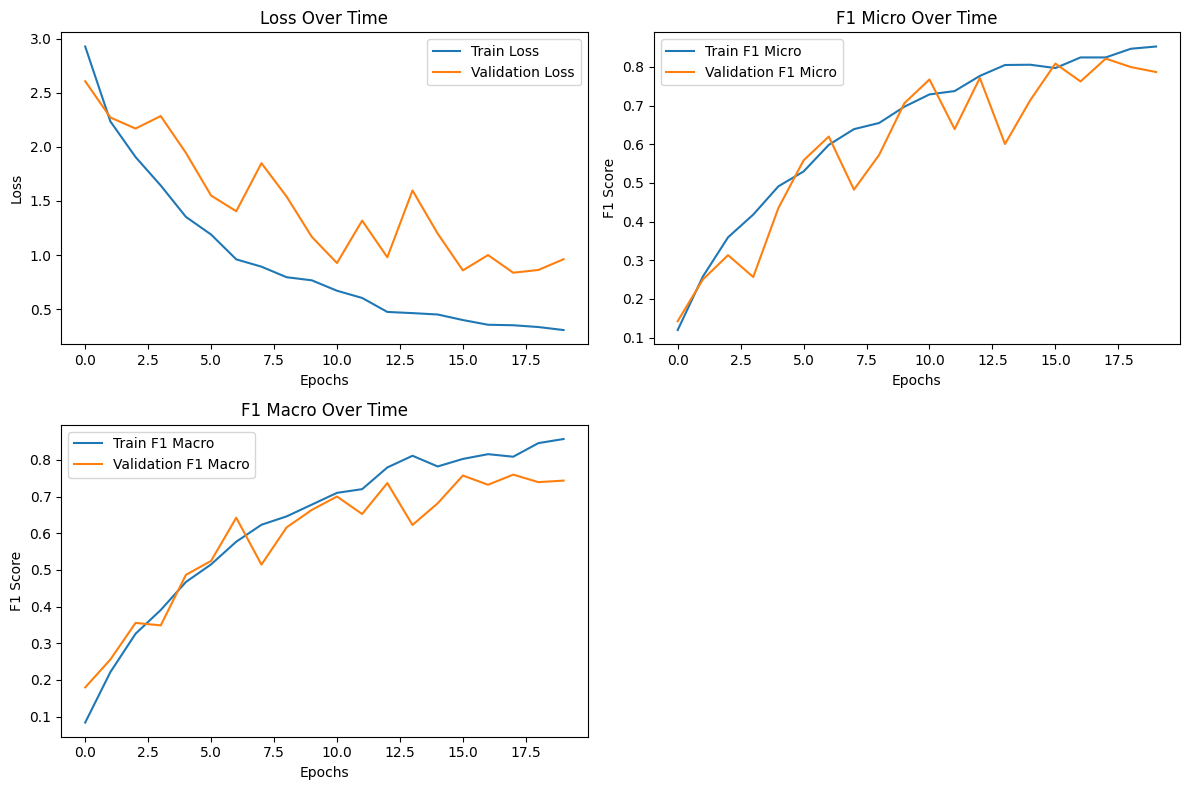

In [ ]:
# === AnomLite Model Architecture ===
# Hybrid model combining MobileNetV2 (spatial features) with LSTM (temporal analysis).
# Designed for lightweight, real-time anomaly detection (~11M parameters).


import torch
import torch.nn as nn
import torchvision.models as models
from torch.nn.utils.rnn import pack_padded_sequence
from sklearn.metrics import f1_score
import numpy as np
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import gc

class AnomLite(nn.Module):
    def __init__(self, num_classes, num_lstm_layers=1, dropout_p=0.0):
        """
        AnomLite: Combines MobileNetV2 for spatial feature extraction
        and LSTM for temporal modeling.
        """
        super(AnomLite, self).__init__()

        mobilenet_v2 = models.mobilenet_v2(pretrained=True)
        self.features = nn.Sequential(*list(mobilenet_v2.features)[:4])
        self.freeze_features = True  # Freeze MobileNetV2 layers initially
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2)  # Downsample

        with torch.no_grad():
            example_input = torch.zeros(1, 3, 64, 64)
            example_output = self.maxpool(self.features(example_input))
            rnn_input_size = example_output.numel()

        self.rnn = nn.LSTM(input_size=rnn_input_size, hidden_size=rnn_input_size, num_layers=num_lstm_layers)

        self.dropout = nn.Dropout(p=dropout_p)
        self.batch_norm = nn.BatchNorm1d(rnn_input_size)

        self.fc = nn.Linear(rnn_input_size, num_classes)

    def forward(self, x, lengths_tensor=None):
        batch_size, sequence_length, C, H, W = x.size()

        x = x.view(batch_size * sequence_length, 3, H, W)
        x = self.features(x)
        x = self.maxpool(x)

        x = torch.flatten(x, start_dim=1)
        x = x.view(batch_size, sequence_length, -1)

        pad_x = pack_padded_sequence(x, lengths=lengths_tensor, batch_first=True, enforce_sorted=False)
        outputs, (hidden_states, _) = self.rnn(pad_x)

        hidden_states = self.dropout(hidden_states[-1])
        hidden_states = self.batch_norm(hidden_states)

        probs = self.fc(hidden_states)

        return probs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_FOLDER = '/content/drive/MyDrive/checkpoints'
MODEL_CHECKPOINT_FOLDER = os.path.join(CHECKPOINT_FOLDER, 'Anomlite_0')
os.makedirs(MODEL_CHECKPOINT_FOLDER, exist_ok=True)


def train_model_with_early_stopping(model, dataloaders, criterion, optimizer, num_epochs=20, patience=5, device='cuda'):
    """
    Optimized training loop with Early Stopping, CUDA cache clearing, and Mixed Precision Training (AMP).
    """
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_f1_micro': [], 'val_f1_micro': [], 'train_f1_macro': [], 'val_f1_macro': []}
    best_val_loss = float('inf')
    no_improvement_epochs = 0
    
    # Initialize Gradient Scaler for Mixed Precision
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(num_epochs):
        # Clear cache at start of epoch
        torch.cuda.empty_cache()
        gc.collect()

        if epoch < 2:
            if model.freeze_features:
                for param in model.features.parameters():
                    param.requires_grad = False
        else:
            if model.freeze_features:
                for param in model.features.parameters():
                    param.requires_grad = True
                model.freeze_features = False

        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            all_preds, all_labels = [], []

            for inputs, labels, lengths_tensor in tqdm(dataloaders[phase], desc=f"{phase}"):
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # Use autocast for mixed precision
                    with torch.cuda.amp.autocast():
                        outputs = model(inputs, lengths_tensor)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        # Use scaler for backward pass and step
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_f1_micro = f1_score(all_labels, all_preds, average='micro')
            epoch_f1_macro = f1_score(all_labels, all_preds, average='macro')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_f1_micro'].append(epoch_f1_micro)
            history[f'{phase}_f1_macro'].append(epoch_f1_macro)

            print(f'{phase} Loss: {epoch_loss:.4f} F1 Micro: {epoch_f1_micro:.4f} F1 Macro: {epoch_f1_macro:.4f}')

            if phase == 'val':
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                    no_improvement_epochs = 0
                    filename = f'anomlite_epoch_{epoch}_loss_{epoch_loss:.4f}_f1_micro_{epoch_f1_micro:.4f}_f1_macro_{epoch_f1_macro:.4f}.pth'
                    torch.save(model.state_dict(), os.path.join(MODEL_CHECKPOINT_FOLDER, filename))
                else:
                    no_improvement_epochs += 1

        if no_improvement_epochs >= patience:
            print("Early stopping triggered!")
            break

    return history



num_classes = len(CLASS_TO_IDX)
model = AnomLite(num_classes=num_classes, num_lstm_layers=1, dropout_p=0.0)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0002)

dataloaders = {'train': train_dataloader, 'val': val_dataloader}

history = train_model_with_early_stopping(model, dataloaders, criterion, optimizer, num_epochs=20, device='cuda')

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history['train_f1_micro'], label='Train F1 Micro')
plt.plot(history['val_f1_micro'], label='Validation F1 Micro')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Micro Over Time')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(history['train_f1_macro'], label='Train F1 Macro')
plt.plot(history['val_f1_macro'], label='Validation F1 Macro')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Macro Over Time')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.nn.functional import softmax
from tqdm import tqdm

def get_all_preds_probs_and_labels(phase, model, device):
    model.to(device).eval()  # [Translated] [Translated] [Translated] [Translated] [Translated] [Translated] отпра[Translated]ляем [Translated] устройст[Translated]о
all_probs = []
    all_labels = []
    with torch.no_grad():  # [Translated], [Translated] [Translated] [Translated] [Translated] [Translated]
        for inputs, labels, lengths_tensor in tqdm(dataloaders[phase], desc=f"{phase} Iteration"):
            inputs, labels = inputs.to(device), labels.to(device)
            lengths_tensor = lengths_tensor.to('cpu').long()  # [Translated] [Translated] [Translated] [Translated] CPU

            outputs = model(inputs, lengths_tensor)  # [Translated] [Translated]
            probs = softmax(outputs, dim=1)  # [Translated] softmax [Translated] [Translated] [Translated]
            all_probs.extend(probs.cpu().numpy())  # [Translated] [Translated]
            all_labels.extend(labels.cpu().numpy())  # [Translated] [Translated] [Translated]
            del inputs, labels, lengths_tensor, outputs, probs

    return all_probs, all_labels

In [ ]:
all_probs, all_labels = get_all_preds_probs_and_labels('val', model, device)

val Iteration: 100%|██████████| 98/98 [02:58<00:00,  1.82s/it]


ROC AUC: 0.97


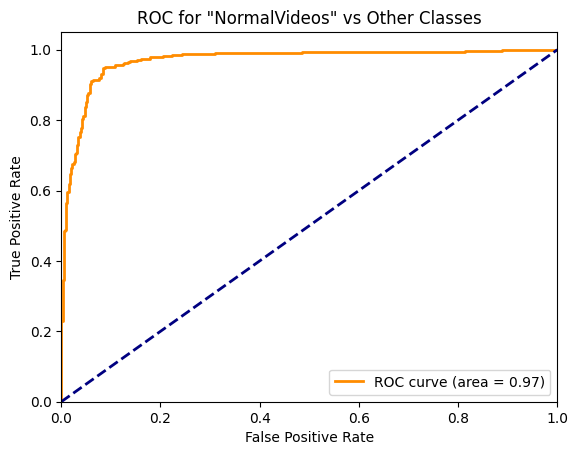

In [ ]:
# === ROC Curve ===
# Receiver Operating Characteristic curve for binary/multiclass evaluation.

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np


all_probs = np.array(all_probs)

normal_class_probs = all_probs[:, CLASS_TO_IDX['NormalVideos']]

all_labels = np.array(all_labels)

binary_labels = (all_labels == CLASS_TO_IDX['NormalVideos']).astype(int)

fpr, tpr, _ = roc_curve(binary_labels, normal_class_probs)

roc_auc = auc(fpr, tpr)

print('ROC AUC: {:.2f}'.format(roc_auc))

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC for "NormalVideos" vs Other Classes')
plt.legend(loc="lower right")
plt.show()

Average Precision (AP): 0.97


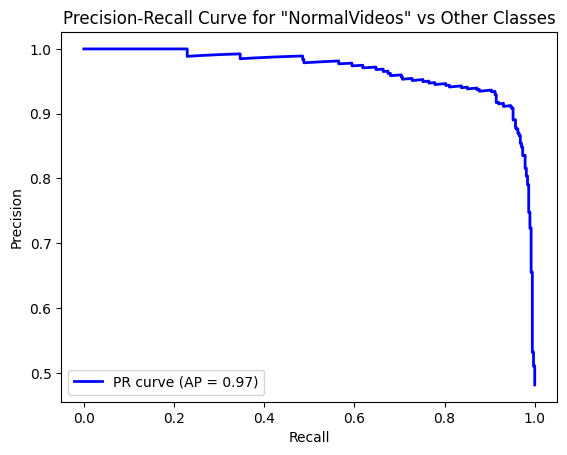


Classification Report:
               precision    recall  f1-score   support

Other Classes       0.78      0.97      0.87       404
 NormalVideos       0.96      0.71      0.81       375

     accuracy                           0.84       779
    macro avg       0.87      0.84      0.84       779
 weighted avg       0.87      0.84      0.84       779


Confusion Matrix:
[[392  12]
 [110 265]]

Multiclass Metrics:
F1-Macro: 0.75
F1-Micro: 0.79
Accuracy: 0.79


In [ ]:
# === Confusion Matrix ===
# Visualize per-class classification performance.

from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report, confusion_matrix

precision, recall, thresholds_pr = precision_recall_curve(binary_labels, normal_class_probs)

average_precision = average_precision_score(binary_labels, normal_class_probs)

print('Average Precision (AP): {:.2f}'.format(average_precision))

plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='PR curve (AP = %0.2f)' % average_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for "NormalVideos" vs Other Classes')
plt.legend(loc="lower left")
plt.show()

print("\nClassification Report:")
binary_predictions = (normal_class_probs >= 0.5).astype(int)  # Threshold at 0.5
print(classification_report(binary_labels, binary_predictions, target_names=['Other Classes', 'NormalVideos']))

print("\nConfusion Matrix:")
print(confusion_matrix(binary_labels, binary_predictions))

from sklearn.metrics import f1_score, accuracy_score

multiclass_f1_macro = f1_score(all_labels, np.argmax(all_probs, axis=1), average='macro')
multiclass_f1_micro = f1_score(all_labels, np.argmax(all_probs, axis=1), average='micro')
multiclass_accuracy = accuracy_score(all_labels, np.argmax(all_probs, axis=1))

print("\nMulticlass Metrics:")
print(f"F1-Macro: {multiclass_f1_macro:.2f}")
print(f"F1-Micro: {multiclass_f1_micro:.2f}")
print(f"Accuracy: {multiclass_accuracy:.2f}")

In [ ]:
   from sklearn.metrics import accuracy_score
   import numpy as np

   idx_to_class = {v: k for k, v in CLASS_TO_IDX.items()}  # Reverse mapping
   predicted_labels = np.argmax(all_probs, axis=1)  # Predicted labels

   per_class_accuracy = {}

   for class_idx in range(len(CLASS_TO_IDX)):
       class_mask = (all_labels == class_idx)

       if np.sum(class_mask) == 0:
           per_class_accuracy[class_idx] = float('nan')  # No samples, assign NaN
           print(f"Class {class_idx} ({idx_to_class[class_idx]}): No samples in dataset.")
           continue

       class_accuracy = accuracy_score(all_labels[class_mask], predicted_labels[class_mask])
       per_class_accuracy[class_idx] = class_accuracy
       print(f"Class {class_idx} ({idx_to_class[class_idx]}): {class_accuracy:.2f}")

   print("\nPer-Class Accuracy:")
   for class_idx, accuracy in per_class_accuracy.items():
       print(f"{class_idx} ({idx_to_class[class_idx]}): {accuracy}")


Class 0 (Abuse): 0.78
Class 1 (Arrest): 0.77
Class 2 (Arson): 0.80
Class 3 (Assault): 0.79
Class 4 (Burglary): 0.82
Class 5 (Explosion): 0.80
Class 6 (Fighting): 0.83
Class 7 (RoadAccidents): 0.82
Class 8 (Robbery): 0.78
Class 9 (Shooting): 0.77
Class 10 (Shoplifting): 0.79
Class 11 (Stealing): 0.85
Class 12 (Vandalism): 0.76
Class 13 (NormalVideos): 0.77

Per-Class Accuracy:
0 (Abuse): 0.782608695652174
1 (Arrest): 0.7727272727272727
2 (Arson): 0.8
3 (Assault): 0.7916666666666666
4 (Burglary): 0.8222222222222222
5 (Explosion): 0.8
6 (Fighting): 0.8333333333333334
7 (RoadAccidents): 0.819672131147541
8 (Robbery): 0.7837837837837838
9 (Shooting): 0.7692307692307693
10 (Shoplifting): 0.7857142857142857
11 (Stealing): 0.8541666666666666
12 (Vandalism): 0.7619047619047619
13 (NormalVideos): 0.7733333333333333


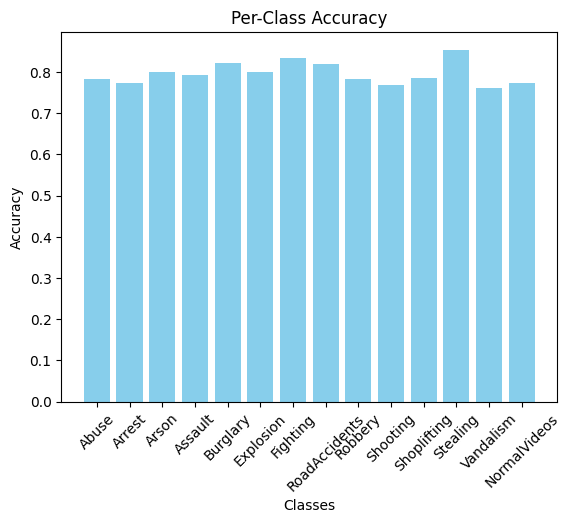

In [ ]:
   import matplotlib.pyplot as plt

   classes = [idx_to_class[idx] for idx in range(len(CLASS_TO_IDX))]
   accuracies = [per_class_accuracy[idx] for idx in range(len(CLASS_TO_IDX))]

   plt.bar(classes, accuracies, color='skyblue')
   plt.xlabel('Classes')
   plt.ylabel('Accuracy')
   plt.title('Per-Class Accuracy')
   plt.xticks(rotation=45)
   plt.show()
